# Comparision between Nelder-Mead, Optimal-Filter and Constrained Optimal Filter

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np
from scipy.optimize import minimize
import seaborn as sns
from datetime import datetime

In [2]:
"""
CONFIGURAÇÕES ===========================================================================================================
"""
k_folds = 10 # números de folds para a validação cruzada k-fold
mode = {  
    # 'save' -> calcula e salva os resultados em .csv's 
    # 'load' -> carrega os resultados
    'nm': 'load', 
    'of2': 'load', 
    'cof': 'load'
    }
show = False # exibe cada resultado separadamente, recomendado "false" se a intenção for apenas a comparação os métodos
"""
==========================================================================================================================
"""

'\n==========================================================================================================================\n'

In [3]:

# s = np.array([0.00002304, 0.01722640, 0.45244500, 1.0, 0.56330700, 0.14933500, 0.04235980])
# i = [30,50,80]

# noise_test = np.array(pd.read_csv(r'.\database\original-database\ruido_ocup80.csv', header=None))
# resultado = np.random.exponential(scale=100, size=(100000, 1))
# r = np.ones((noise_test.shape[0], noise_test.shape[1]))
# r
# for i in range(100000):
#     r[i] = resultado[i]*s + noise_test[i]

# dados = pd.DataFrame(r)
# dados['Amplitude(4)'] = resultado
# dados.to_csv(r'.\database\data_ocup80_sarita.csv', index=False)

In [4]:
# AUXILIARY FUNCTIONS
"""
FUNÇÕES AUXILIARES
"""
## Divisão de treino e teste (não utilizada atualmente)
def trainTestSplit( data, train_prop = 0.5 ):

    threshold = int( len( data ) * train_prop )
    train = data[ : threshold ]
    test = data[ threshold : ]

    return train, test

## Divisão K-Fold
def kFoldSplit(data, k):
    n = len(data)
    fold_size = n // k
    indices = np.arange(n)
    folds = []
    for i in range(k):
        start = i * fold_size
        if i < k - 1:
            end = start + fold_size 
        else:
            end = n
        test_idx = indices[start:end]
        train_idx = np.concatenate([indices[:start], indices[end:]])
        folds.append((train_idx, test_idx))
    return folds

## Calculo dos Erros (resíduos)
def getResidual( real_values, estimated_values, show = False ):

    residuals = np.array(real_values) - np.array(estimated_values)

    if show == True:
        fig, ax = plt.subplots(figsize = (10, 10))
        ax.hist(residuals, bins = 50)
        ax.set_xlabel('Residual Value')
        ax.set_ylabel('Frequency')
        plt.show()
    
    return residuals

## Salva os Resultados Divididos em Fold
def saveKFoldResults(prefix, all_residuals, fold_stats, fold_times, k):
    occ_names = ["occ0_2", "occ0_5", "occ0_7", "occ0_9"]
    
    residuals_dict = {}
    for occ in occ_names:
        residuals_dict[occ] = all_residuals[occ]
    pd.DataFrame(residuals_dict).to_csv(f'.\\results\\{prefix}_residuals.csv', index=False)
    
    # Salva as Estatísticas
    stats_rows = []
    for occ in occ_names:
        for fold_idx, (mean, std) in enumerate(fold_stats[occ]):
            stats_rows.append({
                'occupancy': occ,
                'fold': fold_idx,
                'mean': mean,
                'std': std
            })
    pd.DataFrame(stats_rows).to_csv(f'.\\results\\{prefix}_kfold_stats.csv', index=False)
    
    # Salva o tempo de execução
    times_rows = []
    for occ in occ_names:
        for fold_idx, t in enumerate(fold_times[occ]):
            times_rows.append({
                'occupancy': occ,
                'fold': fold_idx,
                'time': str(t)
            })
    pd.DataFrame(times_rows).to_csv(f'.\\results\\{prefix}_times.csv', index=False)

## Carrega os Resultados
def loadKFoldResults(prefix):
    residuals_df = pd.read_csv(f'.\\results\\{prefix}_residuals.csv')
    stats_df = pd.read_csv(f'.\\results\\{prefix}_kfold_stats.csv')
    times_df = pd.read_csv(f'.\\results\\{prefix}_times.csv')
    return residuals_df, stats_df, times_df

"""
MÉTODOS DE OTIMIZAÇÃO
"""
## OF2 (Optimal Filter)
def optimalFilter2( train, test ):

    def of2Weights( train ):

        pulse = np.array([0.00002304, 0.01722640, 0.45244500, 1.0, 0.56330700, 0.14933500, 0.04235980])
        d_pulse = np.array([0.00004019, 0.00333578, 0.03108120, 0.00000000, -0.02434490, -0.00800683, -0.00243344])

        train = np.array(train).T
        covarianceMatrix = np.cov(train)

        b = np.zeros((10,10))
        b[ 0:7, 0:7 ] = covarianceMatrix
        b[ 0:7, 7 ] = -pulse
        b[ 0:7, 8 ] = -d_pulse
        b[ 0:7, 9 ] = -1
        b[ 7, 0:7 ] = pulse
        b[ 8, 0:7 ] = d_pulse
        b[ 9, 0:7 ] = 1

        c = np.zeros((10, 1))
        c[7] = 1
        
        aux = np.linalg.solve( b, c )
        weights = aux[0:7].flatten()

        return weights

    weights = of2Weights( train )

    sample4 = []
    for i in range(len(test)):
        auxSample = test[i] * weights
        auxSample4 = sum(auxSample)
        sample4.append(auxSample4)

    return sample4

## Nelder-Mead
def nelderMead( train, test ):

    def objectiveFunction(A):
        signalPattern = np.array([
            A[0]*1.0    + A[1]*0.4524   + A[2]*0.0172   + 0             + 0             + 0             + 0,
            A[0]*0.5633 + A[1]*1        + A[2]*0.4524   + A[3]*0.0172   + 0             + 0             + 0,
            A[0]*0.1493 + A[1]*0.5633   + A[2]*1        + A[3]*0.4524   + A[4]*0.0172   + 0             + 0,
            A[0]*0.0424 + A[1]*0.1493   + A[2]*0.5633   + A[3]*1        + A[4]*0.4524   + A[5]*0.0172   + 0,
            0           + A[1]*0.0424   + A[2]*0.1493   + A[3]*0.5633   + A[4]*1        + A[5]*0.4524   + A[6]*0.0172,
            0           + 0             + A[2]*0.0424   + A[3]*0.1493   + A[4]*0.5633   + A[5]*1        + A[6]*0.4524,
            0           + 0             + 0             + A[3]*0.0424   + A[4]*0.1493   + A[5]*0.5633   + A[6]*1
            ])
        aux_sum = samples - signalPattern # "samples" are declared in each iteration of the for loop
        return (sum(aux_sum**2) / len(samples))**0.5
    
    sample4 = []
    for samples in test:
        sample4.append((minimize(objectiveFunction, samples, method='Nelder-Mead', options={'xatol': 1e-4}).x)[3])

    return sample4

## COF (Constrained Optimal Filter)
def constrainedOptimalFilter( train, test ):

    pulse = np.array([0.00002304, 0.01722640, 0.45244500, 1.0, 0.56330700, 0.14933500, 0.04235980])
    S = np.array([
        [pulse[3],   pulse[4],   pulse[5],   pulse[6],   0.0,       0.0,        0.0     ],
        [pulse[2],   pulse[3],   pulse[4],   pulse[5],   pulse[6],  0.0,        0.0     ],
        [pulse[1],   pulse[2],   pulse[3],   pulse[4],   pulse[5],  pulse[6],   0.0     ],
        [pulse[0],   pulse[1],   pulse[2],   pulse[3],   pulse[4],  pulse[5],   pulse[6]],
        [0.0,        pulse[0],   pulse[1],   pulse[2],   pulse[3],  pulse[4],   pulse[5]],
        [0.0,        0.0,        pulse[0],   pulse[1],   pulse[2],  pulse[3],   pulse[4]],
        [0.0,        0.0,        0.0,        pulse[0],   pulse[1],  pulse[2],   pulse[3]]
    ])

    inv_S = np.linalg.inv(S)
    
    sample4 = []
    for samples in test:
        sample4.append( (inv_S @ samples)[3] )

    return sample4   


In [5]:
"""
CARREGA OS DADOS
"""
data = [pd.read_csv(r'database\data_ocup10_sarita.csv'),
        pd.read_csv(r'database\data_ocup30_sarita.csv'),
        pd.read_csv(r'database\data_ocup50_sarita.csv'),
        pd.read_csv(r'database\data_ocup80_sarita.csv')]

columns = data[0].columns # salva os nomes das colunas

In [6]:
def runAlgorithmKFold(algorithm_fn, data, k, columns, show=False):
    occ_names = ["occ0_2", "occ0_5", "occ0_7", "occ0_9"]
    all_residuals = {}
    fold_stats = {}
    fold_times = {}
    
    for i, occ_name in enumerate(occ_names):
        samples_data = np.array(data[i][columns[0:7]])
        amplitudes_data = np.array(data[i][columns[7]])
        
        folds = kFoldSplit(samples_data, k)
        
        occ_residuals_all = []
        occ_fold_stats = []
        occ_fold_times = []
        
        for fold_idx, (train_idx, test_idx) in enumerate(folds):
            trainData = samples_data[train_idx]
            testData = samples_data[test_idx]
            testAmplitude = amplitudes_data[test_idx]
            
            start = datetime.now()
            sample4 = algorithm_fn(trainData, testData)
            elapsed = datetime.now() - start
            occ_fold_times.append(elapsed)
            
            fold_residuals = getResidual(testAmplitude, sample4, show)
            occ_residuals_all.extend(fold_residuals)
            occ_fold_stats.append((np.mean(fold_residuals), np.std(fold_residuals)))
        
        all_residuals[occ_name] = np.array(occ_residuals_all)
        fold_stats[occ_name] = occ_fold_stats
        fold_times[occ_name] = occ_fold_times
    
    return all_residuals, fold_stats, fold_times


def runAlgorithms(data, k, mode, show=False):
    algorithms = {
        'of2': ('of2', optimalFilter2),
        'nm': ('nm', nelderMead),
        'cof': ('cof', constrainedOptimalFilter)
    }
    
    results = {}
    for key, (prefix, fn) in algorithms.items():
        if mode[key] == 'save':
            print(f"Running {key.upper()} with {k}-fold cross-validation...")
            all_residuals, fold_stats, fold_times = runAlgorithmKFold(fn, data, k, columns, show)
            saveKFoldResults(prefix, all_residuals, fold_stats, fold_times, k)
            residuals_df = pd.read_csv(f'.\\results\\{prefix}_residuals.csv')
            stats_df = pd.read_csv(f'.\\results\\{prefix}_kfold_stats.csv')
            times_df = pd.read_csv(f'.\\results\\{prefix}_times.csv')
        else:
            print(f"Loading {key.upper()} results...")
            residuals_df, stats_df, times_df = loadKFoldResults(prefix)
        results[key] = (residuals_df, stats_df, times_df)
    
    return (results['of2'][0], results['of2'][1], results['of2'][2],
            results['nm'][0], results['nm'][1], results['nm'][2],
            results['cof'][0], results['cof'][1], results['cof'][2])

In [7]:
OF2_residuals, OF2_stats, OF2_times, NM_residuals, NM_stats, NM_times, COF_residuals, COF_stats, COF_times = runAlgorithms(data, k_folds, mode, show)

Loading OF2 results...
Loading NM results...
Loading COF results...


In [8]:
"""
DADOS PARA A EXIBIÇÃO
"""
occ_names = ["occ0_2", "occ0_5", "occ0_7", "occ0_9"]
occ = [10, 30, 50, 80]

def extractKFoldMeansStds(stats_df):
    means = []
    means_stds = []
    stds = []
    stds_stds = []
    for occ_name in occ_names:
        occ_data = stats_df[stats_df['occupancy'] == occ_name]
        fold_means = occ_data['mean'].values
        fold_stds = occ_data['std'].values
        means.append(np.mean(fold_means))
        means_stds.append(np.std(fold_means))
        stds.append(np.mean(fold_stds))
        stds_stds.append(np.std(fold_stds))
    return means, means_stds, stds, stds_stds

of2_means, of2_means_stds, of2_stds, of2_stds_stds = extractKFoldMeansStds(OF2_stats)
nm_means, nm_means_stds, nm_stds, nm_stds_stds = extractKFoldMeansStds(NM_stats)
cof_means, cof_means_stds, cof_stds, cof_stds_stds = extractKFoldMeansStds(COF_stats)

def getTotalTime(times_df, occ_name):
    occ_data = times_df[times_df['occupancy'] == occ_name]
    return ', '.join(occ_data['time'].values)

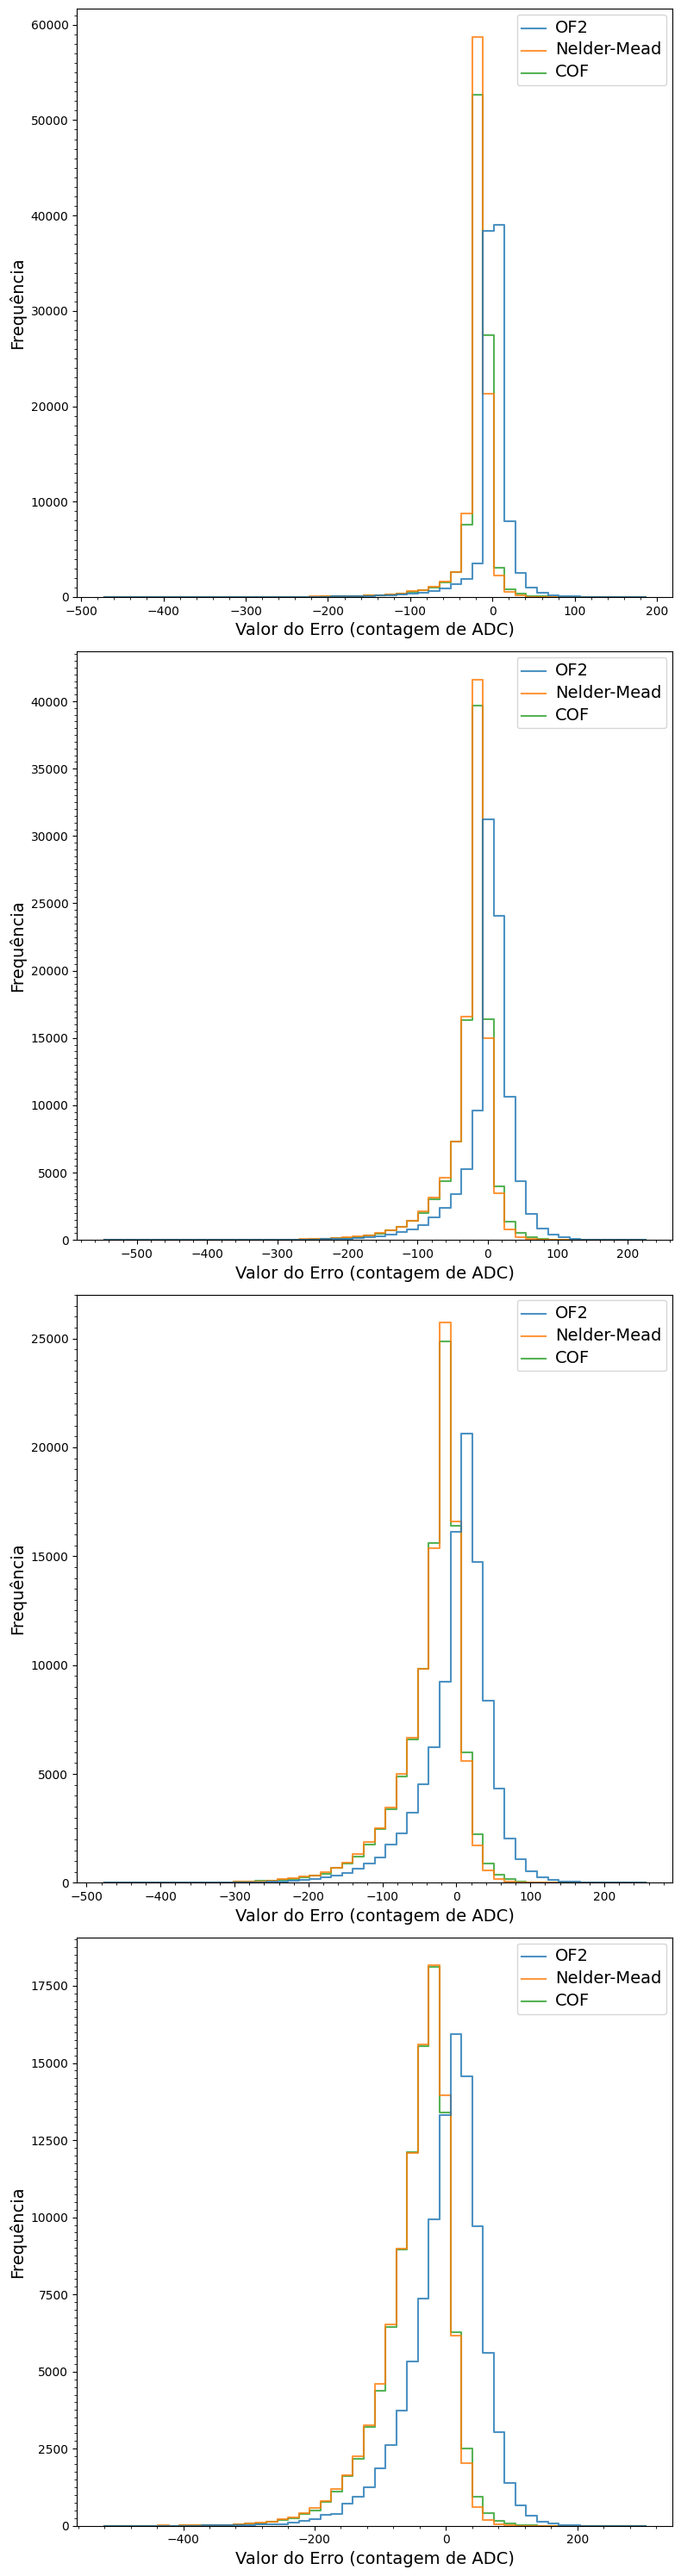

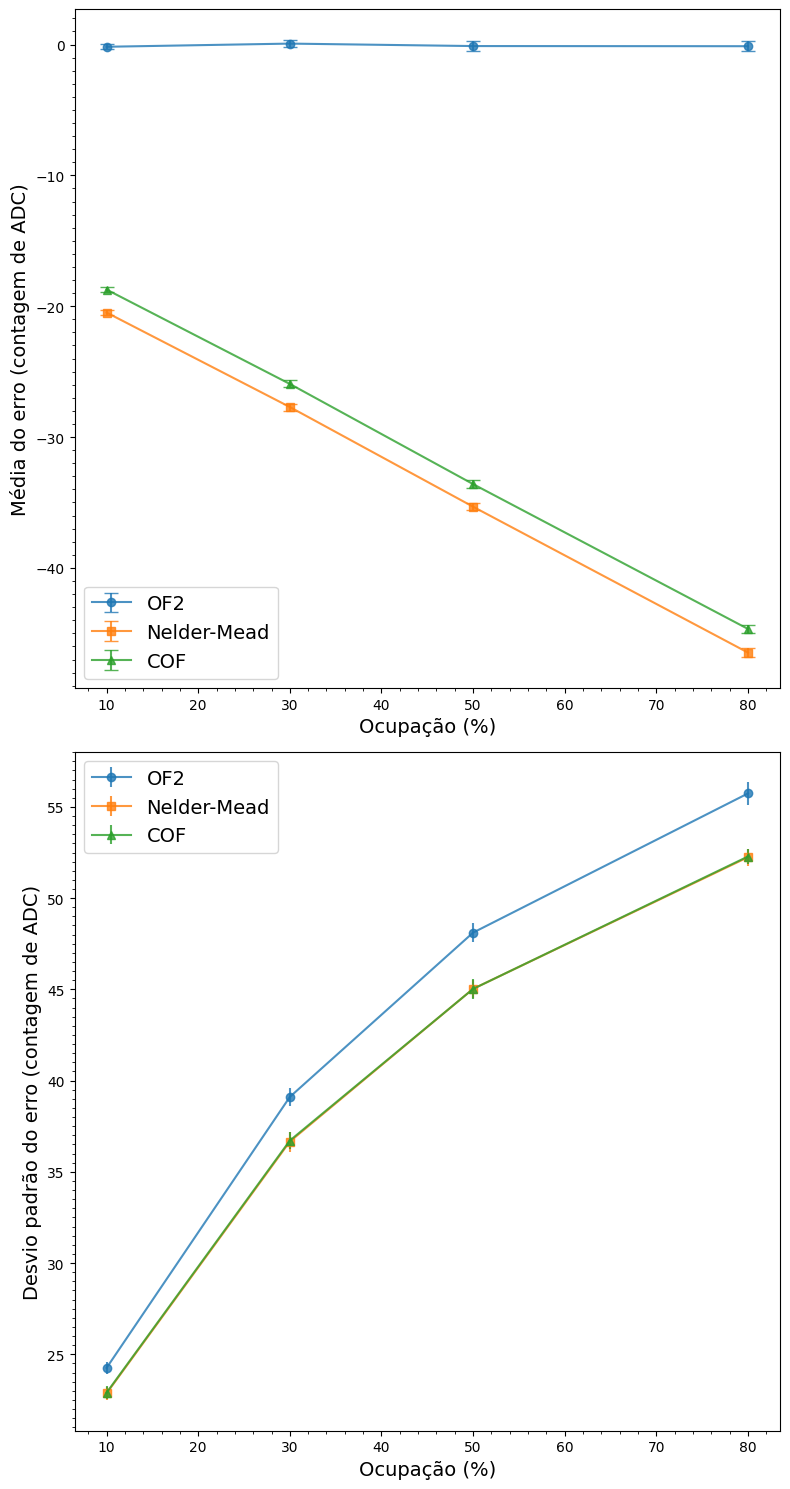

In [9]:
"""
EXIBIÇÃO DOS RESULTADOS
"""
palette = [
    "#1f77b4",  # OF2
    "#ff7f0e",  # Nelder-Mead
    "#2ca02c"   # COF
]

##  Histogramas de erros (erros de todos os k folds)
fig, ax = plt.subplots(nrows = 4, ncols = 1, figsize = (8, 30))
for a in ax:
    a.yaxis.set_minor_locator(AutoMinorLocator(10))
    a.xaxis.set_minor_locator(AutoMinorLocator(5))

for idx, (occ_name, occ_label) in enumerate([
    ("occ0_2", "Dados com  20% de Ocupação"),
    ("occ0_5", "Dados com  50% de Ocupação"),
    ("occ0_7", "Dados com  70% de Ocupação"),
    ("occ0_9", "Dados com  90% de Ocupação"),
]):
    results = pd.concat([
        pd.DataFrame({"Residual Value": OF2_residuals[occ_name].values, "Method": f"OF2"}),
        pd.DataFrame({"Residual Value": NM_residuals[occ_name].values, "Method": f"Nelder-Mead"}),
        pd.DataFrame({"Residual Value": COF_residuals[occ_name].values, "Method": f"COF"}),
    ])
    sns.histplot(data=results, hue="Method", legend=True, x="Residual Value", bins=50, fill=False, ax=ax[idx], element="step", palette=palette, alpha=0.8)
    ax[idx].set_ylabel("Frequência", fontsize=14)
    ax[idx].set_xlabel("Valor do Erro (contagem de ADC)", fontsize=14)
    plt.setp(ax[idx].get_legend().get_texts(), fontsize='14') 
    ax[idx].get_legend().set_title("")
    #ax[idx].set_title(f"{occ_label}")

plt.tight_layout()
plt.show()

## Média dos Erros and Desvio Padrão dos Erros (de cada k fold) 
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = (8, 15))
for a in ax:
    a.yaxis.set_minor_locator(AutoMinorLocator(10))
    a.xaxis.set_minor_locator(AutoMinorLocator(5))

ax[0].errorbar(occ, of2_means, yerr=of2_means_stds, label='OF2', color=palette[0], marker='o', capsize=5, alpha=0.8)
ax[0].errorbar(occ, nm_means, yerr=nm_means_stds, label='Nelder-Mead', color=palette[1], marker='s', capsize=5, alpha=0.8)
ax[0].errorbar(occ, cof_means, yerr=cof_means_stds, label='COF', color=palette[2], marker='^', capsize=5, alpha=0.8)
ax[0].set_xlabel("Ocupação (%)", fontsize=14)
ax[0].set_ylabel("Média do erro (contagem de ADC)", fontsize=14)
#ax[0].set_title(f"Média do erro x Ocupação ({k_folds}-fold)")
ax[0].legend(fontsize=14)

ax[1].errorbar(occ, of2_stds, yerr=of2_stds_stds, label='OF2', color=palette[0], marker='o', alpha=0.8)
ax[1].errorbar(occ, nm_stds, yerr=nm_stds_stds, label='Nelder-Mead', color=palette[1], marker='s', alpha=0.8)
ax[1].errorbar(occ, cof_stds, yerr=cof_stds_stds, label='COF', color=palette[2], marker='^', alpha=0.8)
ax[1].set_xlabel("Ocupação (%)", fontsize=14)
ax[1].set_ylabel("Desvio padrão do erro (contagem de ADC)", fontsize=14)
#ax[1].set_title(f"Desvio padrão do erro x Ocupação ({k_folds}-fold)")
ax[1].legend(fontsize=14)

plt.tight_layout()
plt.show()

In [10]:
"""
TRANSFORMAÇÃO DOS DADOS ORIGINAIS PARA OS DADOS UTILIZADOS PELO ALGORITMO
"""
# import pandas as pd

# def getOriginalData(path):

#     data = pd.read_csv(path)
#     samples = data['sample'].values
#     amplitudes = data['amplitude'].values

#     pulses = []
#     s4_amplitudes = []
#     for i in range( len(samples)-6 ):
#         pulses.append( samples[ i:i+7 ] )
#         s4_amplitudes.append(amplitudes[i+3])

#     return pulses, s4_amplitudes

# datas = [getOriginalData(r'.\database\original-database\occupancy_0.2.CSV'),
#          getOriginalData(r'.\database\original-database\occupancy_0.5.CSV'),
#          getOriginalData(r'.\database\original-database\occupancy_0.7.CSV'),
#          getOriginalData(r'.\database\original-database\occupancy_0.9.CSV')
#          ]

# samples = pd.DataFrame(datas[0][0], columns = [f"sample({i+1})" for i in range(7)])
# amplitudes = pd.DataFrame(datas[0][1], columns = ['AmplitudeSample(4)'])
# data = pd.concat((samples, amplitudes), axis = 1)
# data.to_csv(r'.\database\data_occ0_2.csv', index = False)

# samples = pd.DataFrame(datas[1][0], columns = [f"sample({i})" for i in range(7)])
# amplitudes = pd.DataFrame(datas[1][1], columns = ['AmplitudeSample(4)'])
# data = pd.concat((samples, amplitudes), axis = 1)
# data.to_csv(r'.\database\data_occ0_5.csv', index = False)

# samples = pd.DataFrame(datas[2][0], columns = [f"sample({i})" for i in range(7)])
# amplitudes = pd.DataFrame(datas[2][1], columns = ['AmplitudeSample(4)'])
# data = pd.concat((samples, amplitudes), axis = 1)
# data.to_csv(r'.\database\data_occ0_7.csv', index = False)

# samples = pd.DataFrame(datas[3][0], columns = [f"sample({i})" for i in range(7)])
# amplitudes = pd.DataFrame(datas[3][1], columns = ['AmplitudeSample(4)'])
# data = pd.concat((samples, amplitudes), axis = 1)
# data.to_csv(r'.\database\data_occ0_9.csv', index = False)

'\nTRANSFORMAÇÃO DOS DADOS ORIGINAIS PARA OS DADOS UTILIZADOS PELO ALGORITMO\n'